In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the core files

customers = pd.read_csv('/content/olist_customers_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
items = pd.read_csv('/content/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')

# Quick check

print("Orders:", orders.shape)            # .shape returns (rows, columns)
print("Customers:", customers.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)


In [2]:
orders.head(3)
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [3]:
items.head(3)
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [4]:
reviews.head(3)
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [5]:
payments.head(3)
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [6]:
products.head(3)
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [7]:
customers.head(3)
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [8]:
import os
files = os.listdir('/')
print([f for f in files if 'category' in f.lower()])

[]


In [9]:
translation = pd.read_csv('/content/product_category_name_translation.csv')
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
# Step 1 — Fix datetime columns in orders

# convert all timestamp columns from text to proper datetime

datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col])

orders.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [11]:
orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']

,0
0,8 days 10:28:40
1,13 days 18:46:08
2,9 days 09:27:40
3,13 days 05:00:36
4,2 days 20:58:23
...,...
99436,8 days 05:13:56
99437,22 days 04:38:58
99438,24 days 20:37:34
99439,17 days 02:04:27


In [12]:
# Step 2 Aggregate payments

payments_agg = payments.groupby('order_id'). agg(
    total_payment_value = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type = ('payment_type', 'first')
).reset_index()

print(payments_agg.shape)
print(payments_agg.head(3))

(99440, 4)
                           order_id  total_payment_value  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19   
1  00018f77f2f0320c557190d7a144bdd3               259.83   
2  000229ec398224ef6ca0657da4fc703e               216.87   

   payment_installments payment_type  
0                     2  credit_card  
1                     3  credit_card  
2                     5  credit_card  


In [13]:
# Step 3 — Build the master DataFrame

df = orders.merge(customers, on = 'customer_id', how = 'left')
print("After customers merge:", df.shape)

df = df.merge(items, on = 'order_id', how = 'left')
print("After items merge:", df.shape)

df = df.merge(payments_agg, on = 'order_id', how = 'left')
print("After payments merge:", df.shape)

df = df.merge(reviews[['order_id', 'review_score']], on = 'order_id', how = 'left')
print("After reviews merge:", df.shape)

df = df.merge(products[['product_id', 'product_category_name']], on = 'product_id', how = 'left')
print("After products merge:", df.shape)

After customers merge: (99441, 12)
After items merge: (113425, 18)
After payments merge: (113425, 21)
After reviews merge: (114092, 22)
After products merge: (114092, 23)


In [14]:
# before merging reviews keep only one review per order

reviews_deduped = reviews[['order_id', 'review_score']].drop_duplicates(subset = 'order_id', keep = 'first')
print("Reviews after dedup:", reviews_deduped.shape)

Reviews after dedup: (98673, 2)


In [15]:
# full clean merge

df = orders.merge(customers, on = 'customer_id', how = 'left')      # merging customers in orders based on customer_id
df = df.merge(items, on = 'order_id', how = 'left')                 # merging items into it based on order_id
df = df.merge(payments_agg, on = 'order_id', how = 'left')         # merging payments_agg into it based on order_id
df = df.merge(reviews_deduped, on = 'order_id', how = 'left')       # merging reviews into it based on order_id
df = df.merge(products[['product_id', 'product_category_name']], on = 'product_id', how = 'left')
                             # merging products table with only product_id and product_category_name based on product_id

print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

# .columns returns the column names as a pandas Index object
# .tolist() converts that Index object into a regular Python list — which prints cleaner and is easier to read

Final shape: (113425, 23)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'total_payment_value', 'payment_installments', 'payment_type', 'review_score', 'product_category_name']


In [16]:
# Step 4- Translate category names and add delivery delay column

# translate portugese category names into english

df = df.merge(translation, on = 'product_category_name', how = 'left')

# add delivery delay column = (actual delivery - estimated delivery)
# positive = late, negative = early

df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

#What .dt.days does: Converts the DateTime subtraction into just Day giving  a cleaner integer value easy to compute

print("Shape after translation:", df.shape)
print(df[['product_category_name', 'product_category_name_english', 'delivery_delay_days']].head(5))

Shape after translation: (113425, 25)
   product_category_name product_category_name_english  delivery_delay_days
0  utilidades_domesticas                    housewares                 -8.0
1             perfumaria                     perfumery                 -6.0
2             automotivo                          auto                -18.0
3               pet_shop                      pet_shop                -13.0
4              papelaria                    stationery                -10.0


In [17]:
# check nulls across the full master DataFrame

null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

# df.isnull() — returns True/False for every cell (True = null)
# .sum() — counts the Trues per column (since True = 1, False = 0)
# null_counts[null_counts > 0] — filters to only show columns that actually have nulls.

order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
total_payment_value                 3
payment_installments                3
payment_type                        3
review_score                      961
product_category_name            2378
product_category_name_english    2402
delivery_delay_days              3229
dtype: int64


In [18]:
# cleaning up the nulls

# drop rows where price is null (ghost orders)
df = df.dropna(subset = ['price'])

# fill missing category names with Unknown
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

# final null check
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])
print("Final shape:", df.shape)

order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
total_payment_value                 3
payment_installments                3
payment_type                        3
review_score                      942
product_category_name            1603
delivery_delay_days              2454
dtype: int64
Final shape: (112650, 25)


In [19]:
df = df.copy()
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')

# verify the warning is gone and the Unknown is flled correctly

print(df['product_category_name_english'].isna().sum())
print(df['product_category_name_english'].value_counts().tail(3))

0
product_category_name_english
la_cuisine                   14
fashion_childrens_clothes     8
security_and_services         2
Name: count, dtype: int64


In [20]:
# Analysis 1:

# only look at delivered orders
delivered = df[df['order_status'] == 'delivered'].copy()

# classify each order as late or on the time
delivered['is_late'] = delivered['delivery_delay_days'] > 0

# summary
late_count = delivered['is_late'].sum()
total_count = len(delivered)                                  # late_count/total_count — late orders as a fraction
on_time_pct = round((1 - late_count/total_count) * 100, 2)    # 1 - that fraction — flips it to on-time fraction.
late_pct = round((late_count/total_count) * 100, 2)           # round(..., 2) — rounds to 2 decimal places.

print(f"Total delivered orders: {total_count}")
print(f"On time: {on_time_pct}%")
print(f"Late: {late_pct}%")     # f"..." — f-string. The {} curly braces insert variable values directly into the string.

Total delivered orders: 110197
On time: 93.41%
Late: 6.59%


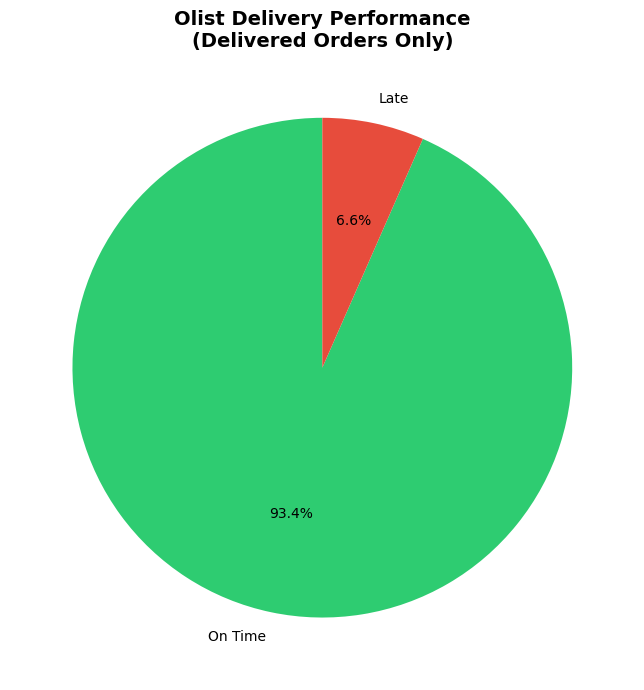

In [21]:
# Visualize this

# pie chart - on time vs late
labels = ['On Time', 'Late']              # labels — the two slice names.
sizes = [on_time_pct, late_pct]           # sizes — the percentage values for each slice.
colors = ['#2ecc71', '#e74c3c']           # colors — green for on time, red for late.

plt.figure(figsize = (7,7))
plt.pie(sizes, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 90)
plt.title('Olist Delivery Performance\n(Delivered Orders Only)', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

# plt.figure(figsize=(7,7)) — sets chart size in inches. Square because pie charts look best square.
# plt.pie() — draws the pie. autopct='%1.1f%%' adds the percentage label inside each slice automatically.
# startangle=90 — rotates the chart so it starts from the top, not the right\
# \n- takes the name later than this under the main title making it look like a subtitle

In [22]:
# Analysis 2: Does being late actually hurts review?

# avg review score - late vs on time
review_by_delivery = delivered.groupby('is_late')['review_score'].mean().round(2)
print(review_by_delivery)


# "Late deliveries correlate with a 46% drop in customer satisfaction scores on the Olist platform — from 4.21 to 2.26 out of 5."

is_late
False    4.21
True     2.26
Name: review_score, dtype: float64


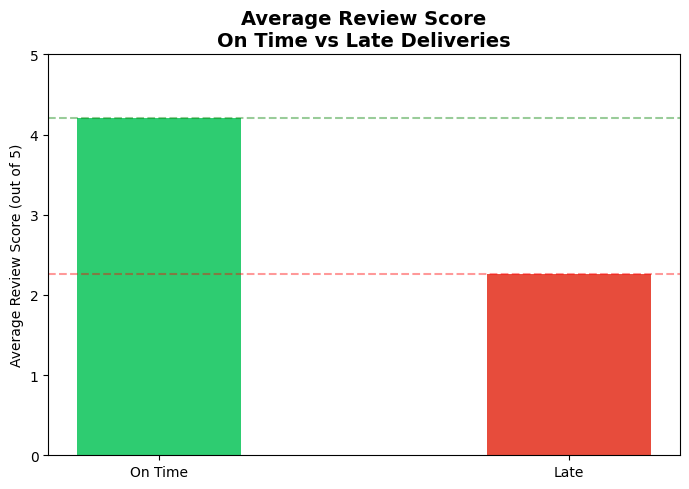

In [23]:
# Visualize this

# bar chart- review score by delivery status
labels = ['On Time', 'Late']
scores = [
    review_by_delivery[False],
    review_by_delivery[True]
]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize = (7, 5))
plt.bar(labels, scores, color = colors, width = 0.4)
plt.ylim(0, 5)
plt.title('Average Review Score\nOn Time vs Late Deliveries', fontsize = 14, fontweight = 'bold')
plt.ylabel('Average Review Score (out of 5)')
plt.axhline(y = scores[0], color = 'green', linestyle = '--', alpha = 0.4)
plt.axhline(y = scores[1], color = 'red', linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.show()

# plt.ylim(0, 5) — forces y axis to go from 0 to 5 since review scores are out of 5.
# plt.ylabel() — adds a label to the y axis.
# plt.axhline() — draws a horizontal reference line. linestyle='--' makes it dashed.
# alpha=0.4 makes it semi-transparent.

In [24]:
# Analysis 3 — Top 10 categories by revenue

category_revenue = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending = False). head(10)
print(category_revenue)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64


/tmp/ipykernel_9017/3167797379.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = category_revenue.values, y = category_revenue.index, palette = 'viridis')


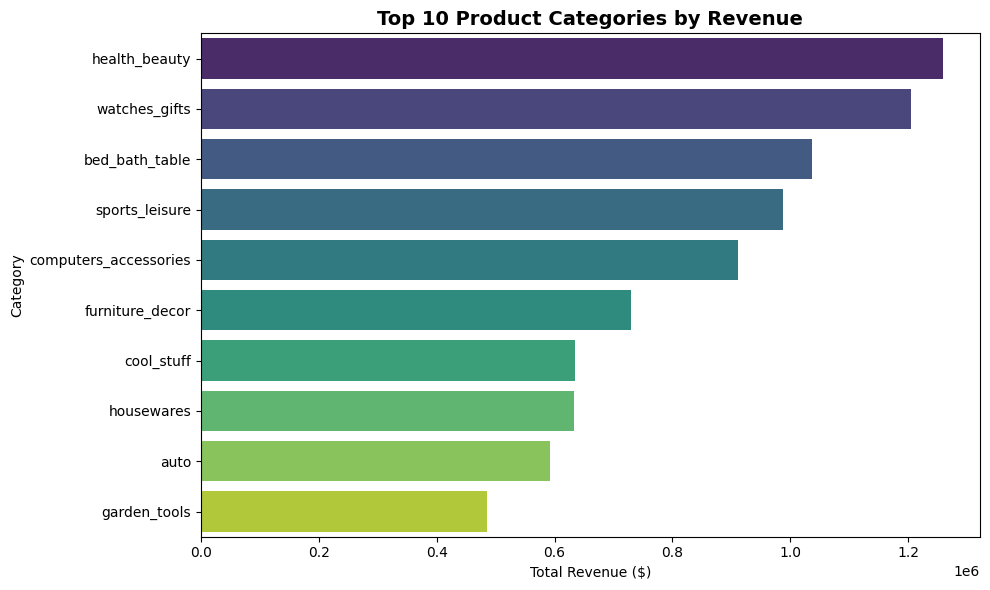

In [25]:
# Visualize this;

plt.figure(figsize = (10, 6))
sns.barplot(x = category_revenue.values, y = category_revenue.index, palette = 'viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize = 14, fontweight = 'bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [26]:
# Analysis 4: Top 10 States by Number of Orders

# count orders per state
state_orders = df.groupby('customer_state')['order_id'].count().sort_values(ascending = False).head(10)
print(state_orders)

customer_state
SP    47449
RJ    14579
MG    13129
RS     6235
PR     5740
SC     4176
BA     3799
DF     2406
GO     2333
ES     2256
Name: order_id, dtype: int64


/tmp/ipykernel_9017/1521419752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = state_orders.values, y = state_orders.index, palette = 'magma')


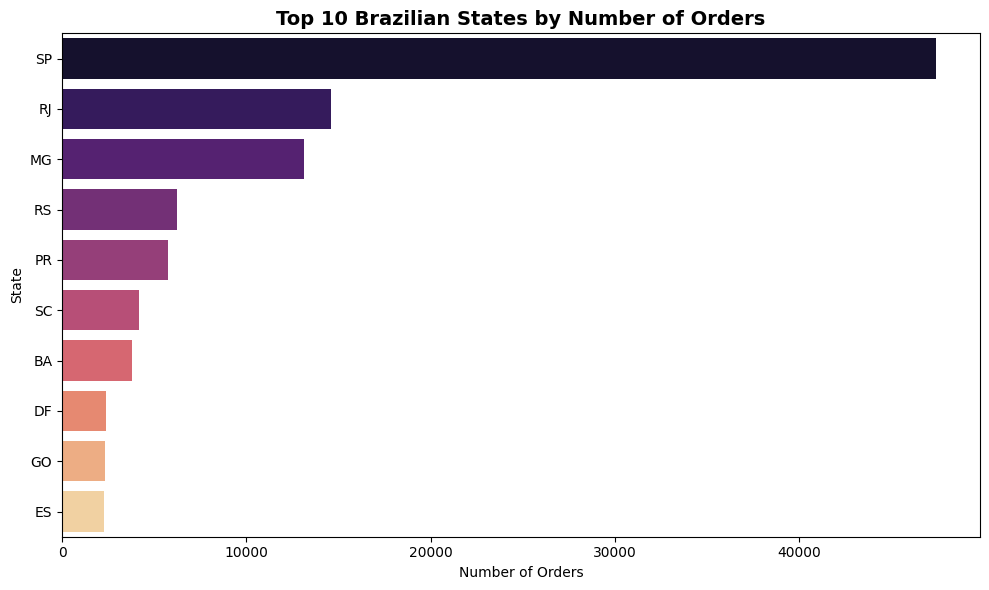

In [27]:
# Visualize this:

plt.figure(figsize = (10, 6))
sns.barplot(x = state_orders.values, y = state_orders.index, palette = 'magma')
plt.title("Top 10 Brazilian States by Number of Orders", fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [28]:
# Analysis 5: Average Delivery Delay by State (Top 10 worst)

# avergae delivery delay by state - only late orders
late_by_state = delivered[delivered['is_late'] == True].groupby('customer_state')['delivery_delay_days'].mean().round(1).sort_values(ascending = False).head(10)
print(late_by_state)

customer_state
AP    96.3
RR    36.4
AM    24.4
AC    18.7
CE    14.7
SE    14.6
RN    14.3
RJ    13.3
PI    12.8
PA    12.5
Name: delivery_delay_days, dtype: float64


/tmp/ipykernel_9017/1901266555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = late_by_state.values, y = late_by_state.index, palette = 'Reds_r')


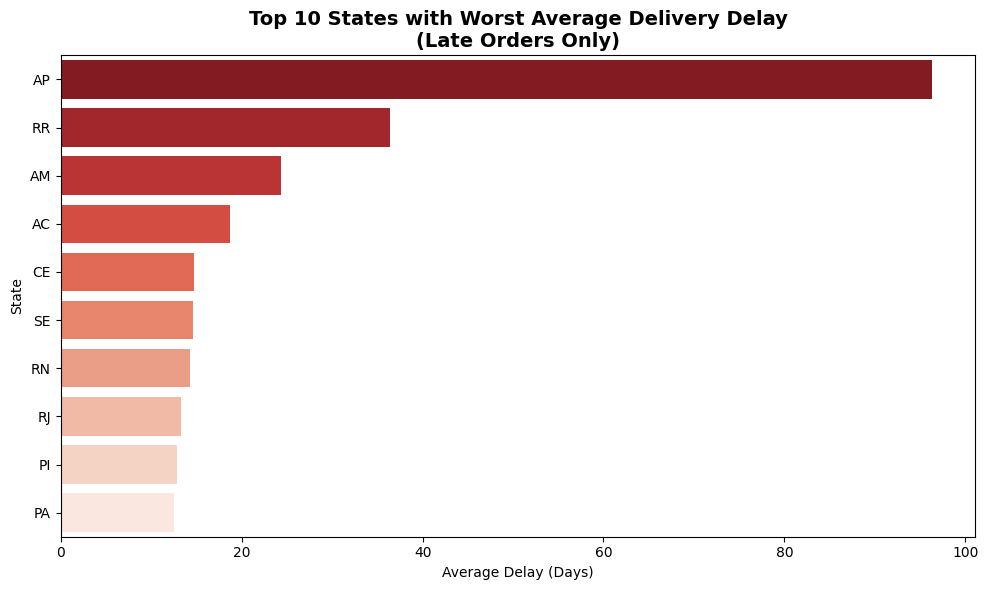

In [29]:
# Visualize this:

plt.figure(figsize = (10, 6))
sns.barplot(x = late_by_state.values, y = late_by_state.index, palette = 'Reds_r')
plt.title("Top 10 States with Worst Average Delivery Delay\n(Late Orders Only)", fontsize = 14, fontweight = 'bold')
plt.xlabel('Average Delay (Days)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [31]:
# Analysis 6: Payment Type Distribution

# Count orders by payment type

payment_counts = df.groupby('payment_type')['order_id'].count().sort_values(ascending = False)
print(payment_counts)

payment_type
credit_card    85194
boleto         22867
voucher         2897
debit_card      1689
Name: order_id, dtype: int64


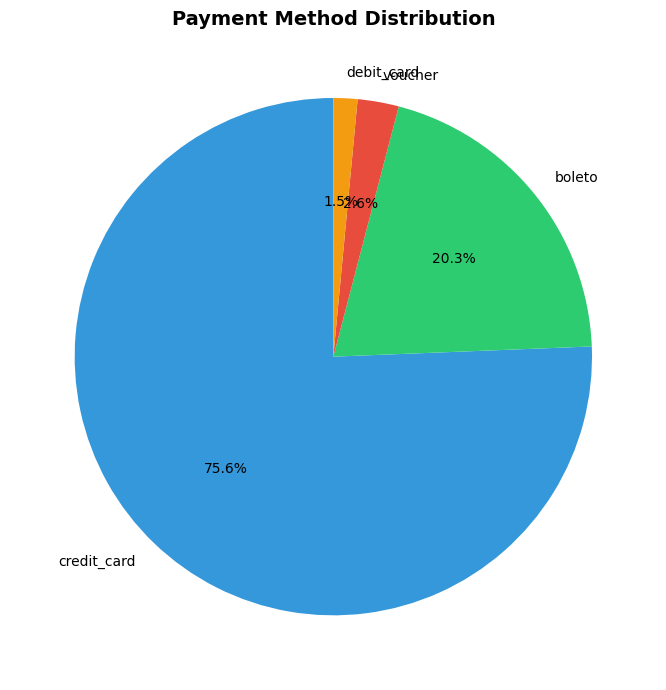

In [32]:
# Visualize this:

plt.figure(figsize = (7, 7))
plt.pie(payment_counts.values, labels = payment_counts.index, autopct = '%1.1f%%',
        colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], startangle = 90)
plt.title('Payment Method Distribution', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [34]:
# Analysis 7: Review Score Distribution

# count of each review score 1 - 5

review_dist = df['review_score'].value_counts().sort_index()
print(review_dist)

review_score
1.0    14127
2.0     3843
3.0     9362
4.0    21203
5.0    63173
Name: count, dtype: int64


/tmp/ipykernel_9017/1012351800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = review_dist.index, y = review_dist.values, palette = 'RdYlGn')


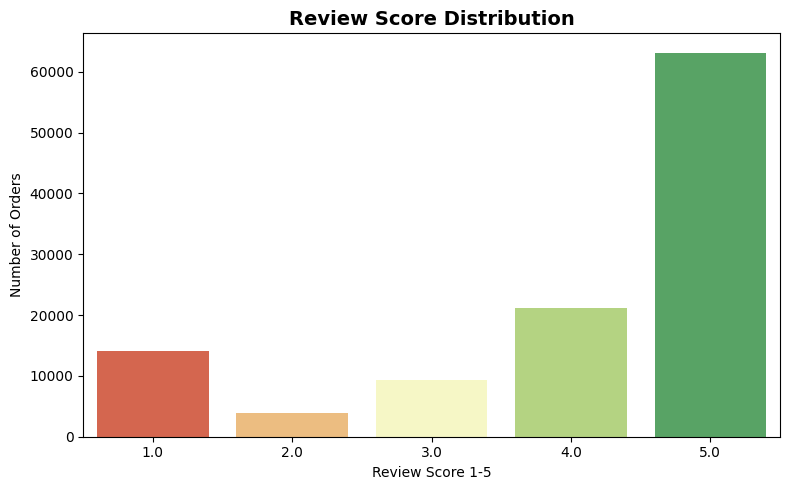

In [36]:
# Visualize this:

plt.figure(figsize = (8, 5))
sns.barplot(x = review_dist.index, y = review_dist.values, palette = 'RdYlGn')
plt.title('Review Score Distribution', fontsize = 14, fontweight = 'bold')
plt.xlabel('Review Score 1-5')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [37]:
# Dual Insight Summary Print

# signature dual insight

print("=" * 55)
print("OLIST E-COMMERCE KEY FINDINGS")
print("=" * 55)

print("\n INSIGHT 1- DELIVERY VS SATISFACTION")
print(f" On-time delivery rate      : {on_time_pct}%")
print(f" Avg review (on time)       : {review_by_delivery[False]} / 5")
print(f" Avg review (late)          : {review_by_delivery[True]} / 5")
print(f" Satisfaction drop          : {round(((review_by_delivery[False] - review_by_delivery[True]) / review_by_delivery[False]) * 100, 1)}%")

print(f"\n INSIGHT 2- REVENUE CONCENTRATION")
top3_revenue = category_revenue.head(3).sum()
total_revenue = df['price'].sum()
top3_pct = round((top3_revenue / total_revenue) * 100, 1)
print(f" Top category               : {category_revenue.index[0]} (R${category_revenue.values[0]:,.0f})")
print(f" Top 3 categories           : {top3_pct}% of total_revenue")
print(f" Total platform revenue     : R${total_revenue:,.0f}")
print("=" * 55)

# {value:,.0f} — formats a number with commas (1,258,681) and 0 decimal places. The , adds thousand separators, .0f means zero decimal float.
# category_revenue.index[0] — gets the name of the first (highest) category from the index.

OLIST E-COMMERCE KEY FINDINGS

 INSIGHT 1- DELIVERY VS SATISFACTION
 On-time delivery rate      : 93.41%
 Avg review (on time)       : 4.21 / 5
 Avg review (late)          : 2.26 / 5
 Satisfaction drop          : 46.3%

 INSIGHT 2- REVENUE CONCENTRATION
 Top category               : health_beauty (R$1,258,681)
 Top 3 categories           : 25.8% of total_revenue
 Total platform revenue     : R$13,591,644


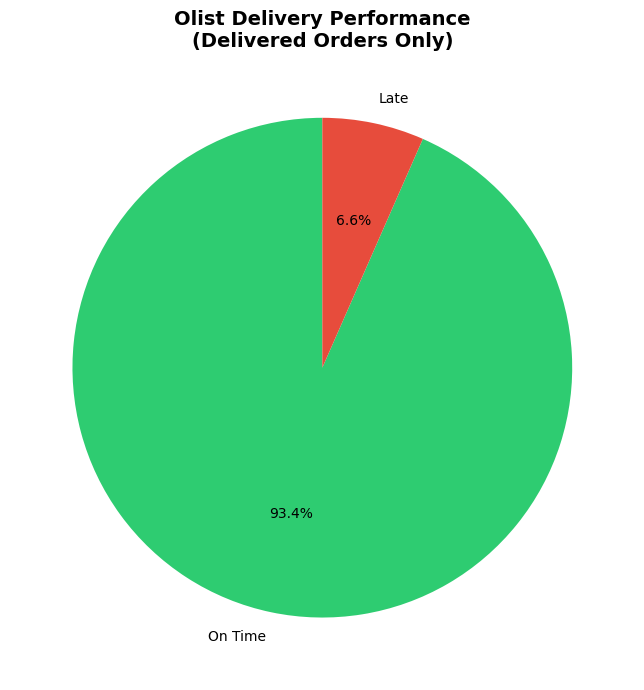

Chart 1 saved ✓


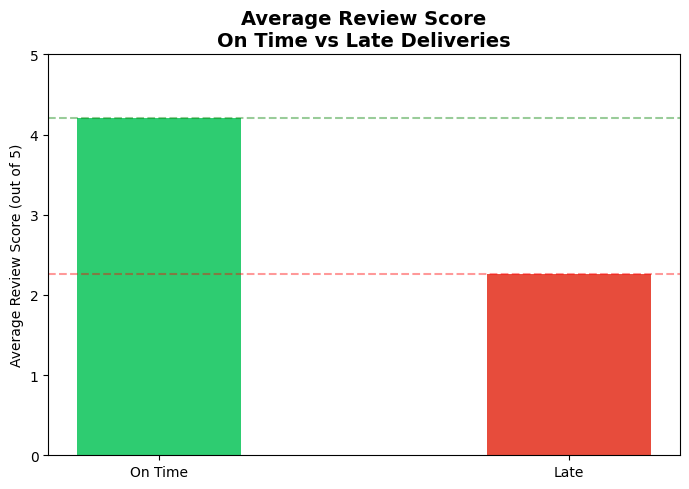

Chart 2 saved ✓


/tmp/ipykernel_9017/3694840215.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')


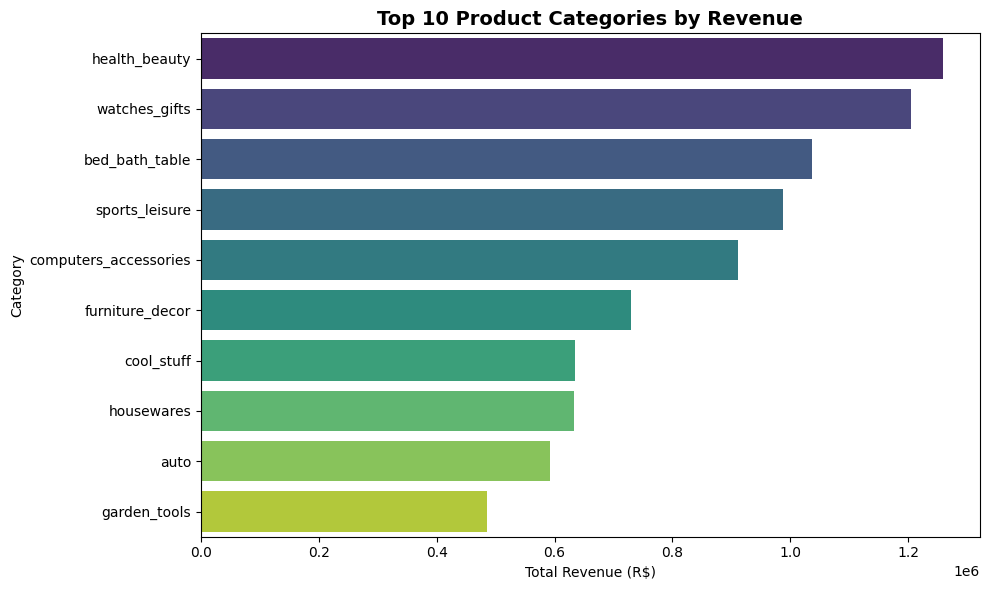

Chart 3 saved ✓


/tmp/ipykernel_9017/3694840215.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_orders.values, y=state_orders.index, palette='magma')


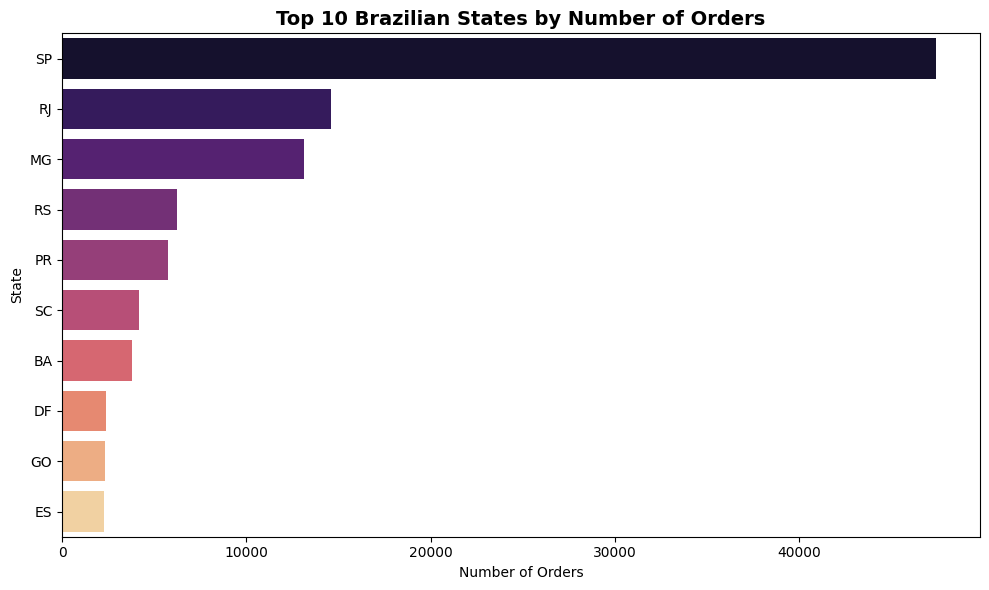

Chart 4 saved ✓


/tmp/ipykernel_9017/3694840215.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_by_state.values, y=late_by_state.index, palette='Reds_r')


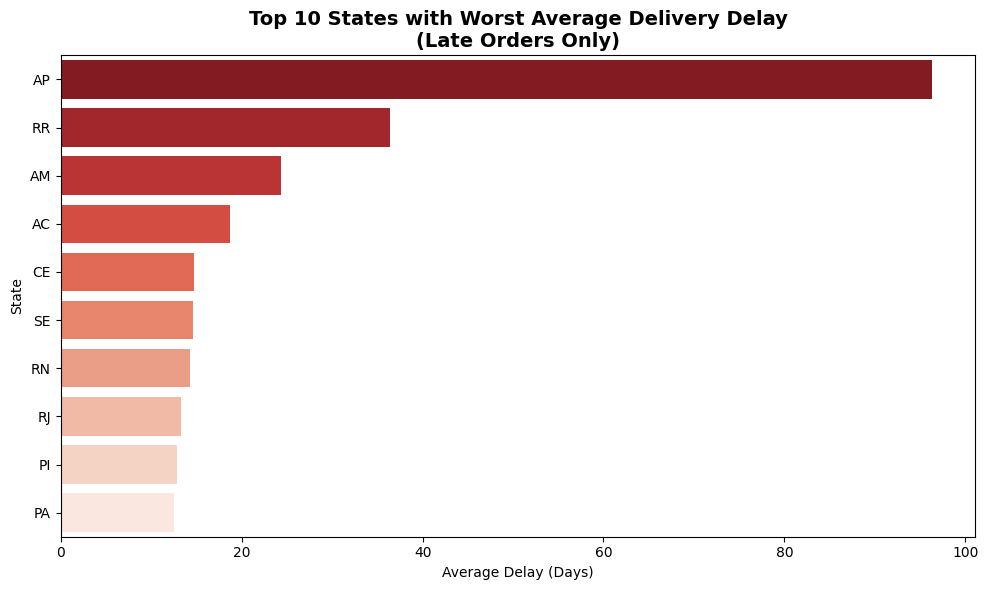

Chart 5 saved ✓


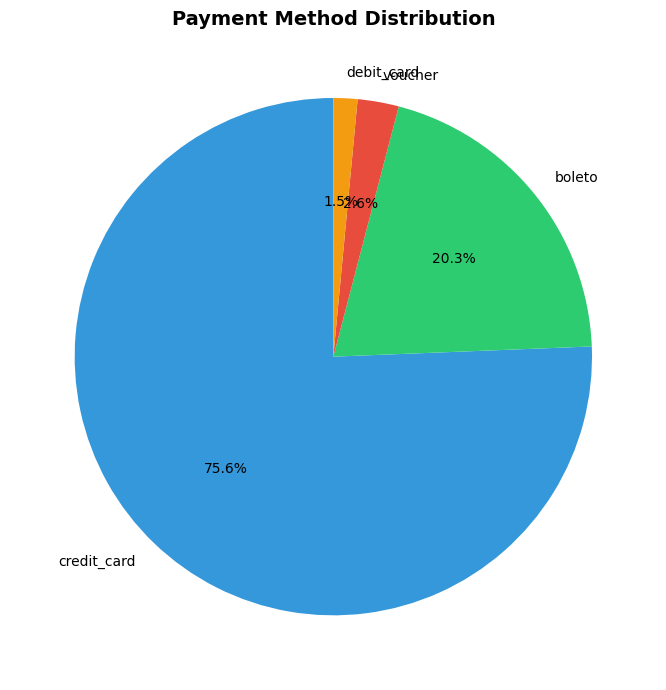

Chart 6 saved ✓


/tmp/ipykernel_9017/3694840215.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=review_dist.index, y=review_dist.values, palette='RdYlGn')


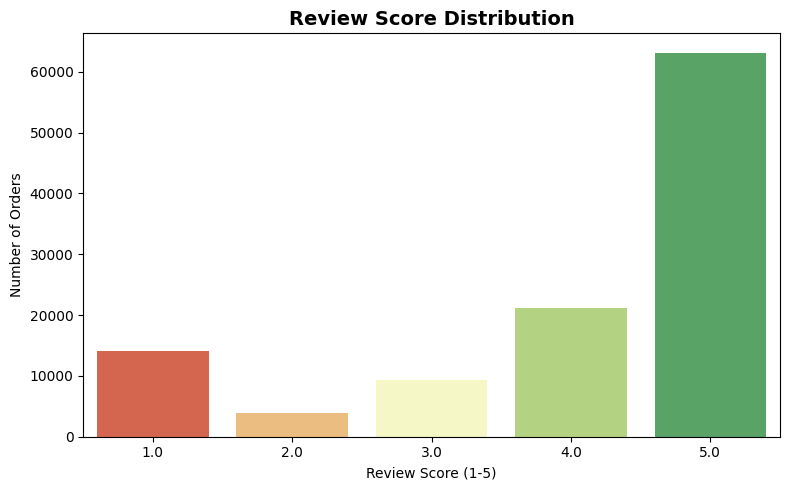

Chart 7 saved ✓

All 7 charts saved successfully.


In [39]:
# Saving all charts for LinkedIn and GitHub

# Chart 1 — Delivery performance pie
labels = ['On Time', 'Late']
sizes = [on_time_pct, late_pct]
plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
plt.title('Olist Delivery Performance\n(Delivered Orders Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✓")

# Chart 2 — Review score by delivery status
scores = [review_by_delivery[False], review_by_delivery[True]]
plt.figure(figsize=(7, 5))
plt.bar(['On Time', 'Late'], scores, color=['#2ecc71', '#e74c3c'], width=0.4)
plt.ylim(0, 5)
plt.title('Average Review Score\nOn Time vs Late Deliveries', fontsize=14, fontweight='bold')
plt.ylabel('Average Review Score (out of 5)')
plt.axhline(y=scores[0], color='green', linestyle='--', alpha=0.4)
plt.axhline(y=scores[1], color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_review_vs_delivery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✓")

# Chart 3 — Top 10 categories by revenue
plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('chart3_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✓")

# Chart 4 — Top 10 states by orders
plt.figure(figsize=(10, 6))
sns.barplot(x=state_orders.values, y=state_orders.index, palette='magma')
plt.title('Top 10 Brazilian States by Number of Orders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('chart4_state_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✓")

# Chart 5 — Top 10 states by delivery delay
plt.figure(figsize=(10, 6))
sns.barplot(x=late_by_state.values, y=late_by_state.index, palette='Reds_r')
plt.title('Top 10 States with Worst Average Delivery Delay\n(Late Orders Only)', fontsize=14, fontweight='bold')
plt.xlabel('Average Delay (Days)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('chart5_delay_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved ✓")

# Chart 6 — Payment method distribution pie
payment_counts = df.groupby('payment_type')['order_id'].count().sort_values(ascending=False)
plt.figure(figsize=(7, 7))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
        colors=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], startangle=90)
plt.title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved ✓")

# Chart 7 — Review score distribution
review_dist = df['review_score'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
sns.barplot(x=review_dist.index, y=review_dist.values, palette='RdYlGn')
plt.title('Review Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart7_review_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved ✓")

print("\nAll 7 charts saved successfully.")